# Reducción de Dimensionalidad: PCA, t-SNE y UMAP

## Explicación Simple con Ecuaciones

**Inteligencia Artificial - Ingeniería Mecatrónica**

---

## ¿Qué es la Reducción de Dimensionalidad?

Imagina que tienes un conjunto de datos con muchas variables (columnas). Cada variable es una **dimensión**. 

**El problema**: Cuando tienes muchas dimensiones, los datos se vuelven **difíciles de visualizar** y **computacionalmente costosos**.

**La solución**: La reducción de dimensionalidad transforma los datos de alta dimensión a **baja dimensión** (2D o 3D) preservando la información más importante.

---

## Los 3 Métodos que Veremos

| Método | Tipo | Idea Principal | Mejor para |
|--------|------|----------------|------------|
| **PCA** | Lineal | Encontrar direcciones de máxima varianza | Interpretación de variables |
| **t-SNE** | No Lineal | Preservar vecinos cercanos | Visualización de clusters |
| **UMAP** | No Lineal | Preservar estructura global y local | Exploración rápida |

---
## 1. PCA - Principal Component Analysis

### ¿Qué es en palabras simples?

**PCA encuentra las direcciones más importantes de tus datos.**

Imagina que tienes puntos en una nube. PCA encuentra las líneas que mejor representan esa nube. La primera línea (PC1) es la dirección donde los puntos están más dispersos. La segunda línea (PC2) es perpendicular a la primera y captura la segunda mayor dispersión.

**Ejemplo visual**: Si tienes datos de estudiantes con notas de matemáticas y física que están correlacionadas, PCA encontraría una línea diagonal que representa el "rendimiento general".

### Ecuaciones Matemáticas

**Paso 1: Estandarizar los datos**

Primero, centramos los datos restando la media y dividiendo por la desviación estándar:

$$ Z = \frac{X - \mu}{\sigma} $$

Donde:
- $X$: Datos originales
- $\mu$: Media de cada columna
- $\sigma$: Desviación estándar de cada columna

**Paso 2: Calcular la matriz de covarianza**

Esta matriz muestra cómo se relacionan las variables entre sí:

$$ \Sigma = \frac{1}{n-1} Z^T Z $$

**Paso 3: Encontrar los componentes principales**

Los componentes principales son los **autovectores** de la matriz de covarianza:

$$ \Sigma \cdot v = \lambda \cdot v $$

Donde:
- $v$: Autovector (dirección del componente)
- $\lambda$: Autovalor (cantidad de varianza explicada)

**Paso 4: Proyectar los datos**

Finalmente, proyectamos los datos en los nuevos ejes:

$$ Y = Z \cdot W $$

Donde $W$ es una matriz con los $k$ autovectores principales.

**Varianza explicada**:

$$ \text{Varianza Explicada} = \frac{\lambda_i}{\sum_{j=1}^{d} \lambda_j} $$

### Ventajas y Desventajas

✅ **Ventajas**:
- Rápido y determinista
- Fácil de interpretar
- Preserva la varianza global

❌ **Desventajas**:
- Solo captura relaciones lineales
- No es bueno para datos con estructura no lineal

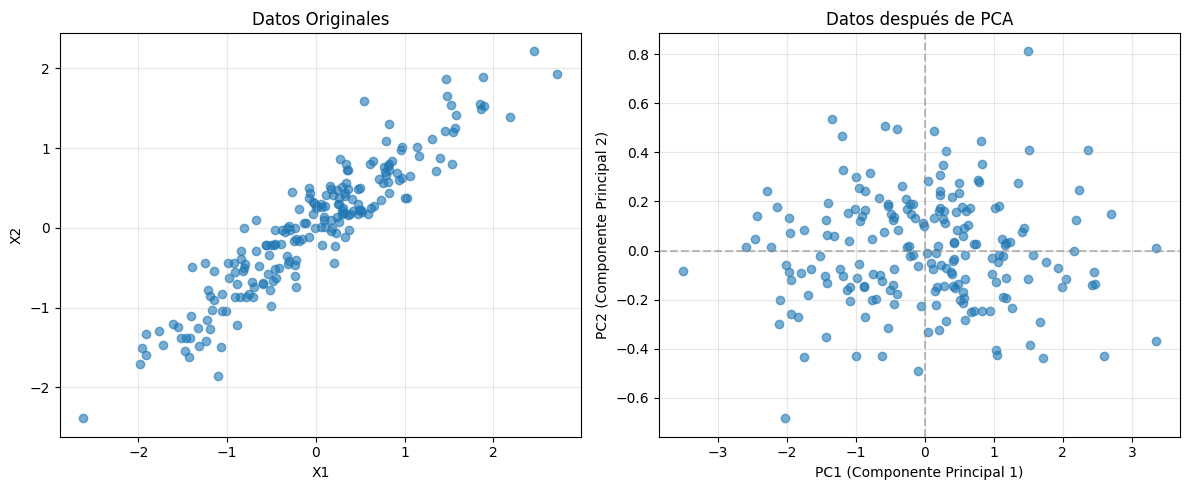

Varianza explicada PC1: 0.968
Varianza explicada PC2: 0.032
Varianza total: 1.000


In [1]:
# Ejemplo simple de PCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Crear datos de ejemplo (2D con correlación)
np.random.seed(42)
n = 200
x = np.random.randn(n)
y = 0.8 * x + 0.3 * np.random.randn(n)
X = np.column_stack([x, y])

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Datos originales
axes[0].scatter(X[:, 0], X[:, 1], alpha=0.6)
axes[0].set_title('Datos Originales')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].grid(True, alpha=0.3)

# Datos transformados
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
axes[1].set_title('Datos después de PCA')
axes[1].set_xlabel('PC1 (Componente Principal 1)')
axes[1].set_ylabel('PC2 (Componente Principal 2)')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Varianza explicada PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"Varianza explicada PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Varianza total: {pca.explained_variance_ratio_.sum():.3f}")

---
## 2. t-SNE - t-Distributed Stochastic Neighbor Embedding

### ¿Qué es en palabras simples?

**t-SNE convierte las distancias entre puntos en probabilidades y las preserva en el espacio de baja dimensión.**

Imagina que tienes puntos en el espacio. t-SNE calcula qué tan similares son los puntos entre sí (probabilidad de ser vecinos). Luego, en el espacio de baja dimensión, coloca los puntos para que las probabilidades de vecindad sean lo más similares posible.

**Ejemplo visual**: Si tienes imágenes de dígitos escritos a mano, t-SNE colocará los "0" juntos, los "1" juntos, etc., preservando la estructura de vecindad.

### Ecuaciones Matemáticas

**Paso 1: Calcular similitudes en el espacio original**

Para cada par de puntos $i$ y $j$, calculamos la probabilidad condicional de que $j$ sea vecino de $i$:

$$ p_{j|i} = \frac{\exp\left(-\frac{||x_i - x_j||^2}{2\sigma_i^2}\right)}{\sum_{k \neq i} \exp\left(-\frac{||x_i - x_k||^2}{2\sigma_i^2}\right)} $$

Donde:
- $||x_i - x_j||$ es la distancia entre puntos
- $\sigma_i$ es un parámetro que controla el tamaño del vecindario

Luego, la similitud simétrica es:

$$ p_{ij} = \frac{p_{j|i} + p_{i|j}}{2} $$

**Paso 2: Calcular similitudes en el espacio proyectado**

En el espacio de baja dimensión, usamos una distribución t-Student (con colas más pesadas):

$$ q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq l} (1 + ||y_k - y_l||^2)^{-1}} $$

**Paso 3: Minimizar la divergencia KL**

El objetivo es hacer que $q_{ij}$ sea lo más parecido posible a $p_{ij}$:

$$ \text{Costo} = \sum_{i \neq j} p_{ij} \log\left(\frac{p_{ij}}{q_{ij}}\right) $$

**Perplejidad**: Controla el número de vecinos considerados:

$$ \text{Perp}(P_i) = 2^{H(P_i)} $$

Donde $H(P_i)$ es la entropía de la distribución de probabilidad.

### Ventajas y Desventajas

✅ **Ventajas**:
- Excelente para visualización de clusters
- Captura estructura no lineal
- Preserva vecindarios locales

❌ **Desventajas**:
- Lento para datos grandes
- No preserva distancias globales
- Resultados sensibles a la perplejidad

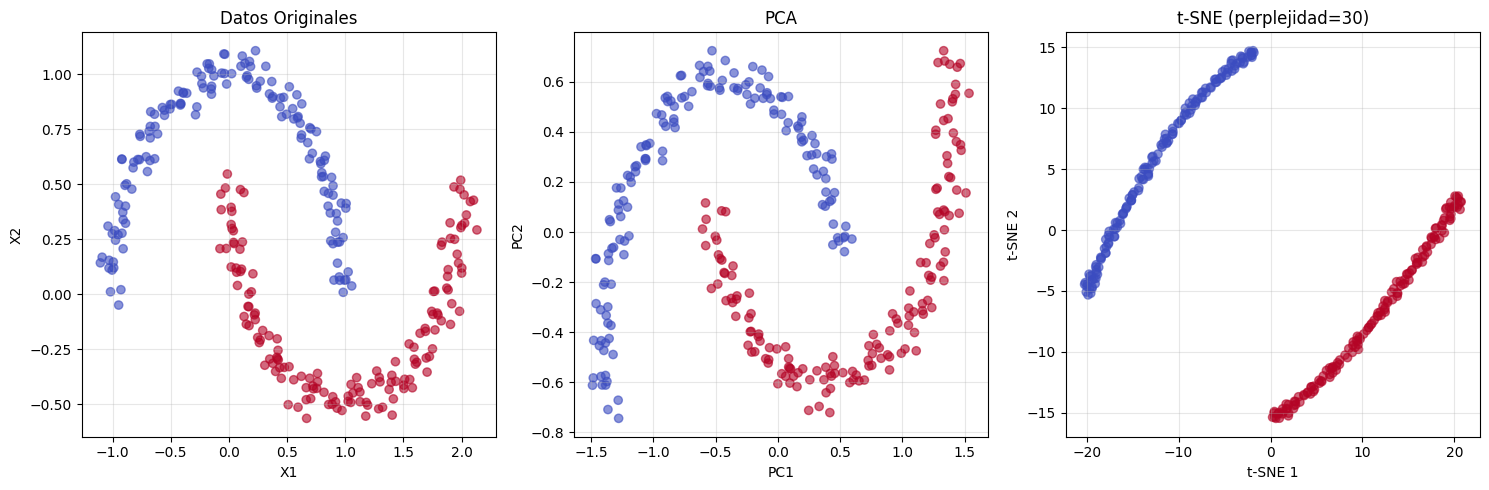

💡 Observa cómo t-SNE separa mejor las dos lunas que PCA.
   PCA intenta preservar la varianza global, mientras que t-SNE
   preserva la estructura de vecindad local.


In [2]:
# Ejemplo simple de t-SNE
from sklearn.manifold import TSNE
from sklearn.datasets import make_moons

# Crear datos de ejemplo (dos lunas)
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# Aplicar PCA para comparar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Aplicar t-SNE con diferentes perplejidades
tsne_5 = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne_5 = tsne_5.fit_transform(X)

tsne_30 = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_30 = tsne_30.fit_transform(X)

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Datos originales
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.6)
axes[0].set_title('Datos Originales')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].grid(True, alpha=0.3)

# PCA
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)
axes[1].set_title('PCA')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(True, alpha=0.3)

# t-SNE
axes[2].scatter(X_tsne_30[:, 0], X_tsne_30[:, 1], c=y, cmap='coolwarm', alpha=0.6)
axes[2].set_title('t-SNE (perplejidad=30)')
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Observa cómo t-SNE separa mejor las dos lunas que PCA.")
print("   PCA intenta preservar la varianza global, mientras que t-SNE")
print("   preserva la estructura de vecindad local.")

---
## 3. UMAP - Uniform Manifold Approximation and Projection

### ¿Qué es en palabras simples?

**UMAP es como una versión mejorada de t-SNE: más rápido, más estable y que preserva mejor la estructura global.**

UMAP asume que los datos están distribuidos en una **variedad** (una superficie curva en el espacio de alta dimensión). Construye un grafo de vecindad y luego encuentra una proyección de baja dimensión que preserva la estructura de este grafo.

**Ejemplo visual**: Si tienes datos de diferentes formas, UMAP mantiene tanto la estructura local (como t-SNE) como la global (como PCA).

### Ecuaciones Matemáticas

**Paso 1: Construir el grafo de vecindad**

Para cada punto $i$, encontramos sus $k$ vecinos más cercanos. La probabilidad de que $i$ y $j$ estén conectados es:

$$ p_{ij} = \exp\left(-\frac{d(x_i, x_j) - \rho_i}{\sigma_i}\right) $$

Donde:
- $d(x_i, x_j)$ es la distancia entre puntos
- $\rho_i$ es la distancia al vecino más cercano
- $\sigma_i$ se ajusta para que $\sum_j p_{ij} = \log_2(k)$

**Paso 2: Construir el grafo en el espacio de baja dimensión**

En el espacio de baja dimensión, la probabilidad de conexión es:

$$ q_{ij} = \left(1 + a \cdot ||y_i - y_j||^{2b}\right)^{-1} $$

Donde $a$ y $b$ son parámetros que controlan la forma de la función.

**Paso 3: Minimizar la divergencia**

UMAP minimiza la divergencia entre $p$ y $q$:

$$ \text{Costo} = \sum_{i \neq j} p_{ij} \log\left(\frac{p_{ij}}{q_{ij}}\right) + (1 - p_{ij}) \log\left(\frac{1 - p_{ij}}{1 - q_{ij}}\right) $$

### Parámetros Clave

**n_neighbors**: Controla el tamaño del vecindario
- **Bajo (2-5)**: Enfoca estructura local
- **Medio (15-30)**: Balance entre local y global
- **Alto (50-100)**: Enfoca estructura global

**min_dist**: Controla la distancia mínima entre puntos en la proyección
- **Bajo (0.01-0.1)**: Clusters más compactos
- **Alto (0.5-1.0)**: Clusters más dispersos

### Ventajas y Desventajas

✅ **Ventajas**:
- Más rápido que t-SNE
- Mejor preservación de estructura global
- Más estable (resultados consistentes)
- Escala a datos grandes

❌ **Desventajas**:
- Menos usado que t-SNE (más nuevo)
- Requiere ajuste de parámetros

h:\Anaconda\envs\deepf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


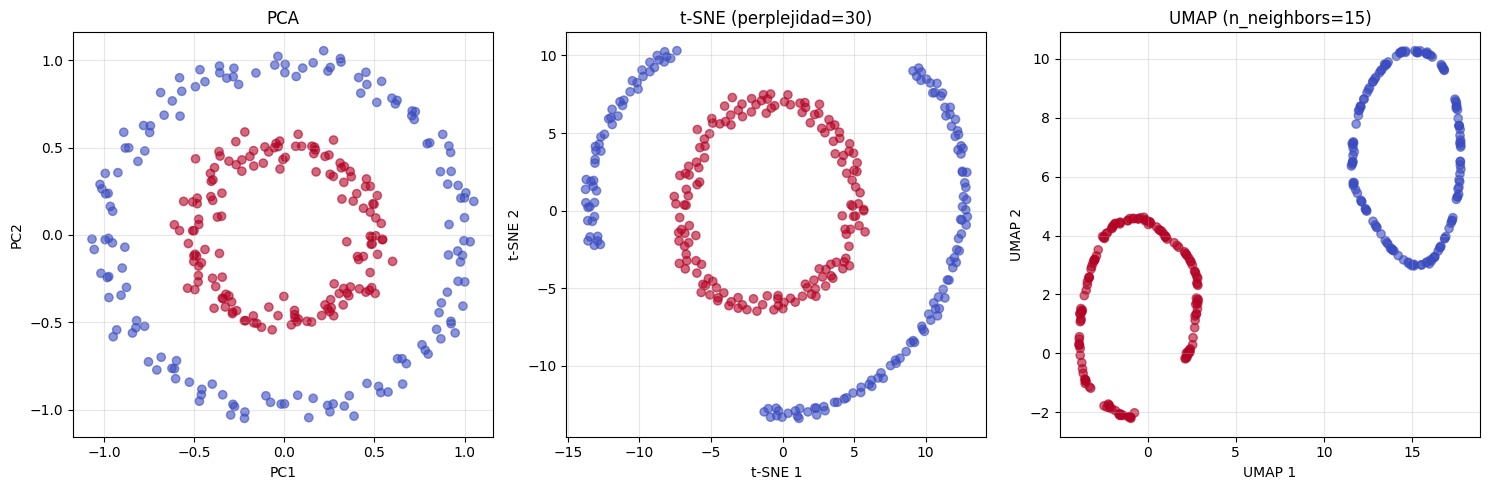

💡 Observaciones:
  - PCA: No logra separar los dos círculos (solo ve estructura lineal)
  - t-SNE: Separa bien los dos círculos (estructura local)
  - UMAP: También separa bien y es más rápido que t-SNE


In [3]:
# Ejemplo simple de UMAP
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("⚠️ UMAP no instalado. Instalar con: pip install umap-learn")

if UMAP_AVAILABLE:
    from sklearn.datasets import make_circles
    
    # Crear datos de ejemplo (círculos concéntricos)
    X, y = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
    
    # Aplicar PCA, t-SNE y UMAP
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(X)
    
    umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = umap_model.fit_transform(X)
    
    # Visualizar comparación
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # PCA
    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)
    axes[0].set_title('PCA')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].grid(True, alpha=0.3)
    
    # t-SNE
    axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', alpha=0.6)
    axes[1].set_title('t-SNE (perplejidad=30)')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    axes[1].grid(True, alpha=0.3)
    
    # UMAP
    axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='coolwarm', alpha=0.6)
    axes[2].set_title('UMAP (n_neighbors=15)')
    axes[2].set_xlabel('UMAP 1')
    axes[2].set_ylabel('UMAP 2')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("💡 Observaciones:")
    print("  - PCA: No logra separar los dos círculos (solo ve estructura lineal)")
    print("  - t-SNE: Separa bien los dos círculos (estructura local)")
    print("  - UMAP: También separa bien y es más rápido que t-SNE")
else:
    print("UMAP no disponible. Ejecuta: pip install umap-learn")

---
## 4. Comparación de Métodos

### Tabla Comparativa

| Característica | PCA | t-SNE | UMAP |
|----------------|-----|-------|------|
| **Tipo** | Lineal | No Lineal | No Lineal |
| **Velocidad** | ⚡ Muy Rápido | 🐢 Lento | ⚡ Rápido |
| **Preserva** | Varianza Global | Estructura Local | Global + Local |
| **Interpretación** | Fácil | Difícil | Media |
| **Determinista** | Sí | No | Casi |
| **Escalable** | Sí | No | Sí |
| **Usar para** | Variables importantes | Clusters | Exploración |

### ¿Cuándo usar cada uno?

**📊 Usar PCA cuando:**
- Quieres entender qué variables son importantes
- Necesitas reducir dimensionalidad para otro modelo
- Tus datos son aproximadamente lineales

**🎯 Usar t-SNE cuando:**
- Quieres visualizar clusters en tus datos
- Tienes datos no lineales (imágenes, texto)
- Tienes un dataset pequeño a mediano

**🚀 Usar UMAP cuando:**
- Quieres visualización rápida
- Tienes datos grandes
- Necesitas balance entre estructura local y global

### Recomendación

**Para la mayoría de los casos, comienza con PCA para entender tus datos, luego usa UMAP para exploración visual, y finalmente t-SNE para visualización de clusters de alta calidad.**

In [4]:
# Resumen final
print("=" * 60)
print("RESUMEN DE REDUCCIÓN DE DIMENSIONALIDAD")
print("=" * 60)
print("\n📊 PCA:")
print("   - Encuentra direcciones de máxima varianza")
print("   - Ecuación clave: Σ·v = λ·v")
print("   - Útil para: Identificar variables importantes")

print("\n🎯 t-SNE:")
print("   - Preserva vecindarios locales")
print("   - Ecuación clave: min KL(P || Q)")
print("   - Útil para: Visualización de clusters")

print("\n🚀 UMAP:")
print("   - Preserva estructura global y local")
print("   - Ecuación clave: Construcción de grafo + embeddding")
print("   - Útil para: Exploración rápida de datos grandes")

print("\n" + "=" * 60)
print("✅ ¡Listo para aplicar a tus datos!")

RESUMEN DE REDUCCIÓN DE DIMENSIONALIDAD

📊 PCA:
   - Encuentra direcciones de máxima varianza
   - Ecuación clave: Σ·v = λ·v
   - Útil para: Identificar variables importantes

🎯 t-SNE:
   - Preserva vecindarios locales
   - Ecuación clave: min KL(P || Q)
   - Útil para: Visualización de clusters

🚀 UMAP:
   - Preserva estructura global y local
   - Ecuación clave: Construcción de grafo + embeddding
   - Útil para: Exploración rápida de datos grandes

✅ ¡Listo para aplicar a tus datos!
